# Objetivo do trabalho
Uso do alexNet para detecção de cancer de intestino

### Download do LC25000 através do kaggle

In [1]:
from google.colab import files
!pip install -q kaggle

In [2]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()

In [3]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.74G/1.76G [00:15<00:00, 36.7MB/s]
100% 1.76G/1.76G [00:15<00:00, 121MB/s] 


## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

### Datasets e dataLoader

In [4]:
!ls

dataset_config.py	   lc25000_dataset.py
dataset_formater.py	   lung-and-colon-cancer-histopathological-images.zip
drive			   lung_colon_image_set
get_dataloaders.py	   sample_data
get_formatted_datasets.py  train_and_test_model.py


In [5]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders

In [6]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 16258.74it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [7]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test)

### Modelo e treinamento
- AlexNet
- inChannels: 3
- OutputFeatures: 2

In [8]:
import torch
import torchvision

In [9]:
in_channels = 3
output_features = 2

In [10]:
class Alexnet(torch.nn.Module):
    def __init__(self, in_channels, output_features):
        super(Alexnet, self).__init__()
        model = torchvision.models.alexnet(num_classes=output_features)
        model.features[0] = torch.nn.Conv2d(
            in_channels, 64,
            kernel_size=11, stride=4, padding=2
        )
        self.model = model

    def forward(self, x):
        return self.model(x)

model = Alexnet(in_channels=in_channels, output_features=output_features)


In [12]:
from train_and_test_model import train_model, test_model

In [16]:
model = model.to("cuda")

In [17]:
train_losses, val_losses = train_model(model, dataloader_train, dataloader_validation)

Epoch 1: Train Loss = 0.6959 | Val Loss = 0.6743
Epoch 2: Train Loss = 0.6781 | Val Loss = 0.5968
Epoch 3: Train Loss = 0.5812 | Val Loss = 0.3120
Epoch 4: Train Loss = 0.4798 | Val Loss = 0.2724
Epoch 5: Train Loss = 0.4254 | Val Loss = 0.2089
Epoch 6: Train Loss = 0.3039 | Val Loss = 0.0909
Epoch 7: Train Loss = 0.2253 | Val Loss = 0.0899
Epoch 8: Train Loss = 0.1624 | Val Loss = 0.0384
Epoch 9: Train Loss = 0.1497 | Val Loss = 0.0739
Epoch 10: Train Loss = 0.1354 | Val Loss = 0.0356


#### imprimindo resultados do treinamento e validação

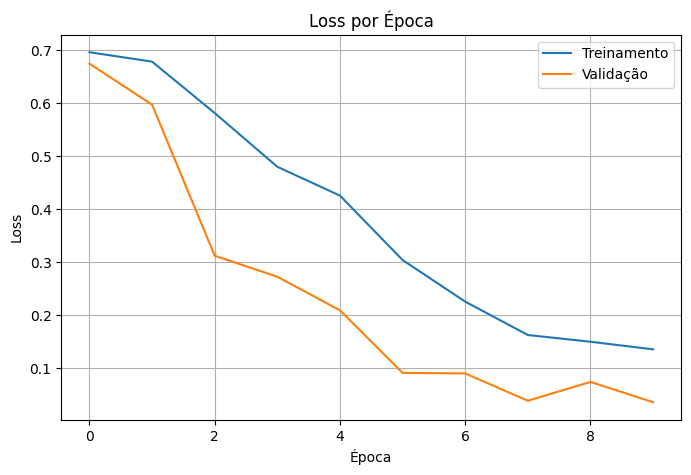

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Testando modelo

In [19]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.9780
Precisão (weighted): 0.9782
Recall (weighted): 0.9780
F1-score (weighted): 0.9780
Matriz de Confusão:
[[968  32]
 [ 12 988]]


In [20]:
from tabulate import tabulate
import seaborn as sns

In [23]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.978  │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9782 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.978  │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.978  │
╘═════════════════════╧═════════╛


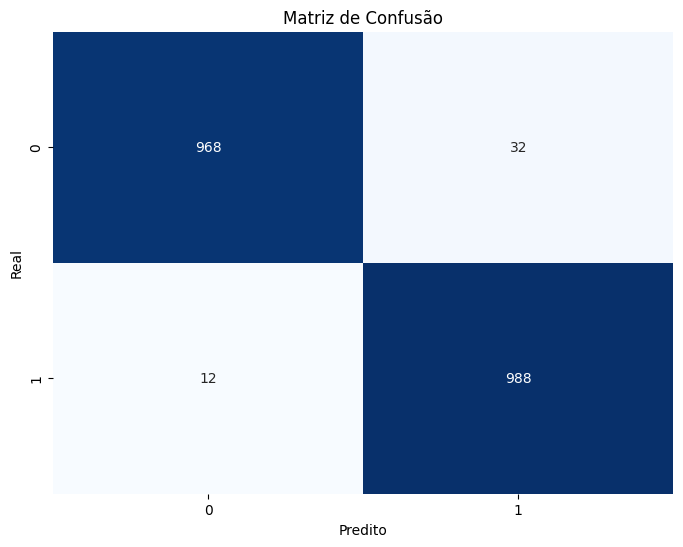

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()